In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from matplotlib.colors import to_rgb

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [4]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [5]:
# ---------------- six-bin region grid ----------------
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6

tree = cKDTree(
    np.column_stack([X_grid.ravel(), Y_grid.ravel()])
)

_, idx = tree.query(
    np.column_stack([df_ameda.xc, df_ameda.yc])
)

region_map = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

df_ameda['Region'] = (
    pd.Series(bin_grid.ravel()[idx])
      .map(region_map)
)


In [6]:
df_ameda['h'] = h[df_ameda.ic, df_ameda.jc]

df_eddies_shelf = df_ameda[df_ameda.Region.isin(['S1','S2'])]
df_eddies_shelf.Eddy.unique()


array([  12,   17,   18,   22,   30,   33,   62,   63,  103,  104,  110,
        117,  121,  133,  146,  154,  156,  164,  171,  199,  202,  205,
        213,  222,  227,  228,  232,  247,  257,  266,  282,  314,  316,
        320,  327,  328,  331,  341,  343,  345,  348,  353,  356,  361,
        366,  375,  377,  410,  425,  431,  434,  453,  465,  466,  470,
        485,  491,  493,  495,  497,  498,  508,  520,  522,  526,  532,
        544,  549,  568,  574,  585,  589,  592,  594,  601,  603,  613,
        623,  625,  629,  646,  654,  655,  664,  665,  669,  677,  678,
        681,  684,  687,  700,  712,  719,  720,  723,  725,  732,  739,
        746,  750,  752,  753,  755,  759,  772,  774,  782,  799,  811,
        823,  824,  841,  846,  855,  859,  870,  873,  876,  879,  882,
        891,  900,  918,  919,  926,  934,  941,  945,  949,  954,  956,
        976,  979,  981,  986, 1005, 1007, 1022, 1030, 1032, 1033, 1034,
       1040, 1047, 1056, 1057, 1063, 1066, 1069, 10

(-46.17100351627474, 1595.0627775687858)

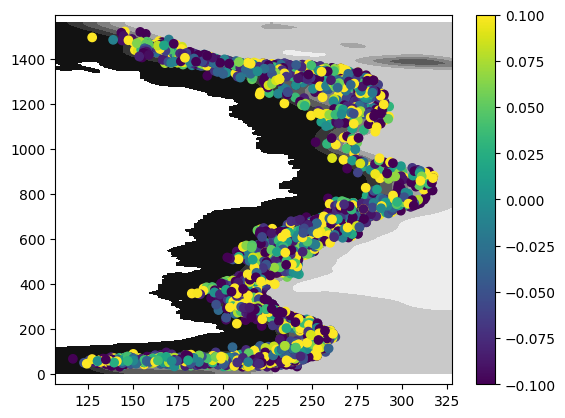

In [7]:

for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.scatter(df.xc, df.yc, c=df.TiltDis)
plt.colorbar()
xlim = plt.xlim()
ylim = plt.ylim()
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey', zorder=0)
plt.xlim(xlim); plt.ylim(ylim)
# plt.axis('equal')


Text(0.5, 0, 'Tilt bearing - slope bearing [deg]')

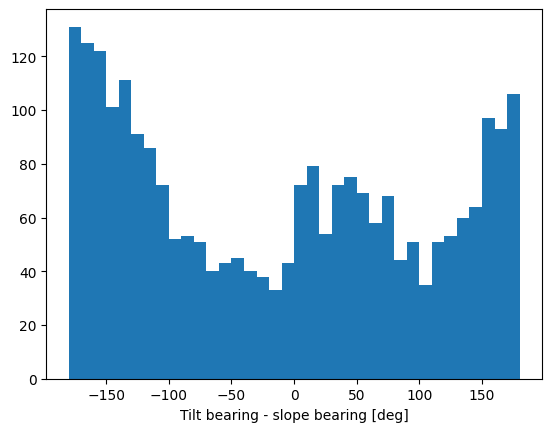

In [12]:
# rounded version
dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdx,
    colname="gx",
    circle_region_flag=True
)

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdy,
    colname="gy",
    circle_region_flag=True
)

df_eddies_shelf['slope_bearing'] = (90 - np.degrees(np.arctan2(df_eddies_shelf.gx, df_eddies_shelf.gy)) + 20) % 360

df_eddies_shelf['theta'] = ((df_eddies_shelf.TiltDir - df_eddies_shelf.slope_bearing + 180) % 360) - 180

df_eddies_shelf = df_eddies_shelf[df_eddies_shelf.Eddy.isin(df_eddies_shelf.Eddy.unique())].copy()

plt.hist(df_eddies_shelf.theta, bins=np.arange(-180, 181, 10))
plt.xlabel('Tilt bearing - slope bearing [deg]')


In [41]:
def plot_single_eddy_tilt(
    eddy, df_eddies,
    X_grid, Y_grid, h, mask_rho,
    gap=5, s=5, figsize=(7, 7),
    tilt_dir_offset=-20,
    ax=None,
    cbar=False,
    color=None,
    A_flag=True
):
    def point_b(a, r, theta_deg):
        theta_rad = np.radians(theta_deg)
        dx = r * np.sin(theta_rad)
        dy = r * np.cos(theta_rad)
        return a[0] - dx, a[1] - dy

    def darken(color, factor=0.7):
        r, g, b = to_rgb(color)
        return (r * factor, g * factor, b * factor)

    df_eddy = df_eddies.loc[df_eddies.Eddy.eq(eddy)].sort_values('Day').copy()

    if len(df_eddy) == 0:
        raise ValueError(f'Eddy {eddy} not found')

    cyc = df_eddy.Cyc.iloc[0]
    if color is None:
        color = 'c' if cyc == 'CE' else 'r'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    m = ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho, h / 1e3, np.nan),
        cmap='gray'
    )

    ax.plot(df_eddy.xc, df_eddy.yc, color=color, linewidth=0.5, zorder=1)

    for d, data in df_eddy.iterrows():

        x0, y0 = data.xc, data.yc
        tilt_dis = data.TiltDis
        tilt_dir = data.TiltDir

        if np.isnan(tilt_dis) or np.isnan(tilt_dir):
            ax.scatter(
                x0, y0,
                edgecolors=darken(color, 0.8),
                facecolors='none',
                s=15,
                zorder=3
            )
            continue

        xb, yb = point_b(
            [x0, y0],
            tilt_dis,
            (tilt_dir + tilt_dir_offset) % 360
        )

        ax.plot([x0, xb], [y0, yb], color=color, zorder=2)
        ax.scatter(x0, y0, color=darken(color, 0.8), s=s, zorder=3)

    if A_flag:
        ax.text(
            df_eddy.iloc[0].xc + 15,
            df_eddy.iloc[0].yc + 15,
            'A',
            color='r',
            fontsize=14
        )

    ax.set_title(f'{cyc}{eddy}')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    if cbar:
        cb = fig.colorbar(m, ax=ax, location='right', shrink=0.7)
        cb.set_label('Bathymetry (km)')

    return fig, ax, m
    

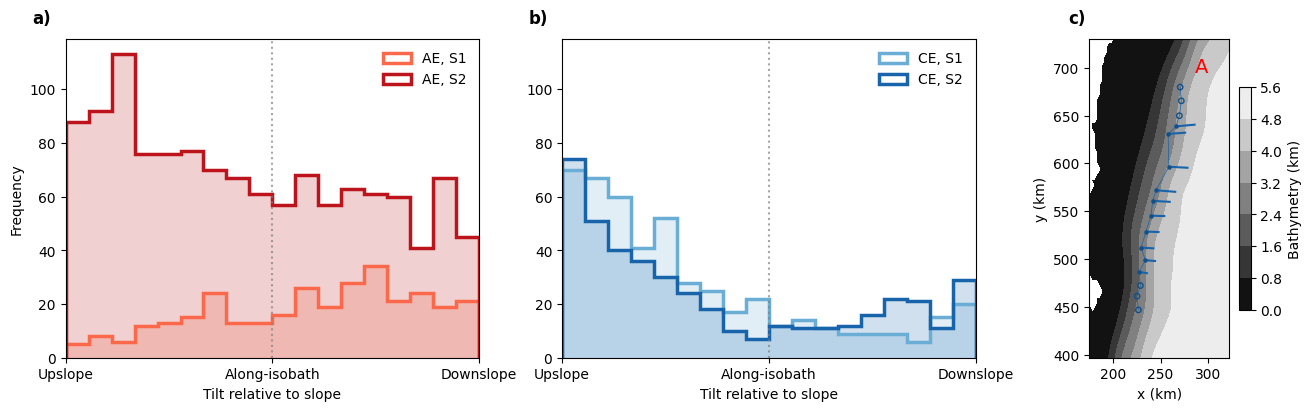

In [51]:
fig, axs = plt.subplots(
    1, 3,
    figsize=(13, 4),
    gridspec_kw={'width_ratios': [1, 1, .5]},
    constrained_layout=True
)

bins = np.arange(0, 181, 10)

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

for ax, cyc in zip(axs, ['AE', 'CE']):

    df = df_eddies_shelf[df_eddies_shelf.Cyc == cyc]

    theta_s1 = 180 - np.abs(
        df.loc[df.Region == 'S1', 'theta'].dropna()
    )

    theta_s2 = 180 - np.abs(
        df.loc[df.Region == 'S2', 'theta'].dropna()
    )

    if cyc == 'AE':
        colors = [reds(0.5), reds(0.8)]
    else:
        colors = [blues(0.5), blues(0.8)]
        
    counts1, edges = np.histogram(theta_s1, bins)
    counts2, _ = np.histogram(theta_s2, bins)
    
    width = np.diff(edges)

    ax.hist(
        theta_s1,
        bins=bins,
        color=colors[0],
        alpha=0.2,
        histtype='stepfilled'
    )
    
    ax.hist(
        theta_s2,
        bins=bins,
        color=colors[1],
        alpha=0.2,
        histtype='stepfilled'
    )
    
    ax.hist(
        theta_s1,
        bins=bins,
        histtype='step',
        linewidth=2.5,
        color=colors[0],
        label=f'{cyc}, S1'
    )
    
    ax.hist(
        theta_s2,
        bins=bins,
        histtype='step',
        linewidth=2.5,
        color=colors[1],
        label=f'{cyc}, S2'
    )

    ax.axvline(90, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Upslope',
        'Along-isobath',
        'Downslope'
    ])

    ax.set_xlim(0, 180)
    ax.legend(frameon=False)

    if cyc == 'AE':
        ylim = ax.get_ylim()
    else:
        ax.set_ylim(ylim)
        
axs[0].set_ylabel('Frequency')
axs[0].set_xlabel('Tilt relative to slope')
axs[1].set_xlabel('Tilt relative to slope')

# Region map
eddy = 1851
_,_,_= plot_single_eddy_tilt(
    eddy, df_eddies_shelf,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[2],
    color=blues(0.8),
    A_flag=True,
    cbar=True
)
axs[2].set_title('')

axs[0].text(-0.08, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')

axs[1].text(-0.08, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')

axs[2].text(-0.15, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold')

plt.show()


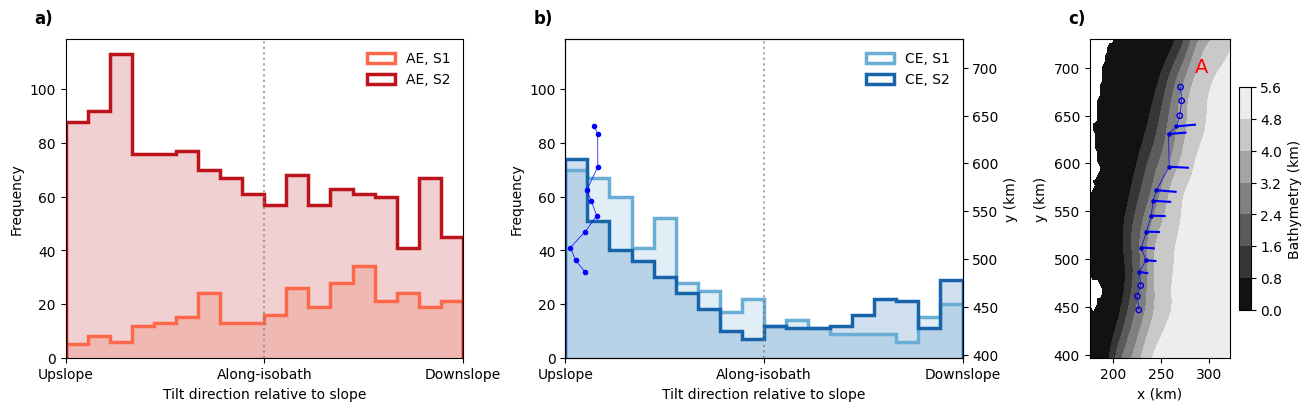

In [64]:
fig, axs = plt.subplots(
    1, 3,
    figsize=(13, 4),
    gridspec_kw={'width_ratios': [1, 1, .5]},
    constrained_layout=True
)

bins = np.arange(0, 181, 10)

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

for ax, cyc in zip(axs[:2], ['AE', 'CE']):

    df = df_eddies_shelf[df_eddies_shelf.Cyc == cyc]

    theta_s1 = 180 - np.abs(df.loc[df.Region == 'S1', 'theta'].dropna())
    theta_s2 = 180 - np.abs(df.loc[df.Region == 'S2', 'theta'].dropna())

    colors = [reds(0.5), reds(0.8)] if cyc == 'AE' else [blues(0.5), blues(0.8)]

    ax.hist(theta_s1, bins=bins, color=colors[0], alpha=0.2, histtype='stepfilled')
    ax.hist(theta_s2, bins=bins, color=colors[1], alpha=0.2, histtype='stepfilled')

    ax.hist(theta_s1, bins=bins, histtype='step', linewidth=2.5,
            color=colors[0], label=f'{cyc}, S1')
    ax.hist(theta_s2, bins=bins, histtype='step', linewidth=2.5,
            color=colors[1], label=f'{cyc}, S2')

    ax.axvline(90, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(['Upslope', 'Along-isobath', 'Downslope'])
    ax.set_xlim(0, 180)
    ax.legend(frameon=False)

    if cyc == 'AE':
        ylim = ax.get_ylim()
    else:
        ax.set_ylim(ylim)

    ax.set_ylabel('Frequency')
    ax.set_xlabel('Tilt direction relative to slope')

eddy = 1851

_, _, _ = plot_single_eddy_tilt(
    eddy, df_eddies_shelf,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[2],
    color='b',#blues(0.8),
    A_flag=True,
    cbar=True
)

axs[2].set_title('')

df = df_eddies_shelf[df_eddies_shelf.Eddy == eddy].copy()

ax1_twin = axs[1].twinx()
ax1_twin.plot(
    180 - df.theta.abs(),
    df.yc,
    '-o',
    color='b',
    markersize=3,
    linewidth=.5
)

ax1_twin.set_ylim(axs[2].get_ylim())
ax1_twin.set_ylabel('y (km)')
ax1_twin.tick_params(axis='y', labelright=True)

axs[0].text(-0.08, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')

axs[1].text(-0.08, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')

axs[2].text(-0.15, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold')

plt.show()

